# 00 — Data Pipeline v2
**Rochester PD Narrative Bias Analysis**

Full data pipeline: load → deduplicate → quality audit → enhanced redaction (Claude API) → train/test split design.

**Fixes from v1:**
- Deduplication by CR# (v1 had 5297 rows but only 2974 unique CR numbers)
- Enhanced redaction using Claude Haiku (v1 GPT-4o only removed 38.5% of race terms)
- NER-based identifier detection
- Proper temporal + stratified split documentation

In [1]:
import sys, os
sys.path.insert(0, '../../notebooks')
import config

import json
import re
import pandas as pd
from tqdm.notebook import tqdm
import anthropic
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.makedirs(config.ANALYSIS_OUT, exist_ok=True)
os.makedirs(config.FIGURES_DIR, exist_ok=True)
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(config.REDACTED_DATA_DIR, exist_ok=True)

print('Config loaded. Outputs →', config.ANALYSIS_OUT)


Config loaded. Outputs → ../../notebooks/analysis/outputs


## 1. Load Primary Dataset

In [2]:
with open(config.PRIMARY_DATA) as f:
    raw = json.load(f)

# Handle both flat list and wrapped {"metadata":..., "records":[...]} formats
if isinstance(raw, dict):
    records = raw.get('records', raw.get('data', list(raw.values())[-1]))
else:
    records = raw

df = pd.DataFrame(records)
print(f'Raw records: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nRace distribution (raw):')
print(df['race'].value_counts())
print(f'\nYear distribution:')
print(df['year'].value_counts().sort_index())


Raw records: 5297
Columns: ['cr_number', 'date', 'year', 'narrative', 'subject_description', 'race', 'gender', 'force_used', 'subject_resistance']

Race distribution (raw):
race
Black       2277
Unknown     2024
White        814
Hispanic     171
Asian         11
Name: count, dtype: int64

Year distribution:
year
2015     622
2016     688
2017     414
2018     738
2019     698
2022    2137
Name: count, dtype: int64


## 2. Deduplication by CR Number

In [3]:
# Check duplicate CR numbers
cr_counts = df['cr_number'].value_counts()
dups = cr_counts[cr_counts > 1]
print(f'Total records: {len(df)}')
print(f'Unique CR numbers: {df["cr_number"].nunique()}')
print(f'Duplicate CR numbers: {len(dups)}')
print(f'Records in duplicates: {(cr_counts[cr_counts > 1]).sum()}')
print(f'\nTop duplicate CRs:')
print(dups.head(10))

# Inspect a duplicate to understand why
if len(dups) > 0:
    sample_cr = dups.index[0]
    dupe_rows = df[df['cr_number'] == sample_cr]
    print(f'\nSample duplicate CR {sample_cr}:')
    print(dupe_rows[['cr_number', 'year', 'race', 'gender', 'narrative_length' if 'narrative_length' in df.columns else 'narrative']].head())

Total records: 5297
Unique CR numbers: 2974
Duplicate CR numbers: 220
Records in duplicates: 2543

Top duplicate CRs:
cr_number
                1554
N/A              333
Not found         94
22-000000         15
Not Found          9
Not provided       8
16-241860          7
19-220673          7
22-031931          7
Redacted           7
Name: count, dtype: int64

Sample duplicate CR :
     cr_number  year     race   gender  \
231             2015    White     Male   
3161            2022  Unknown  Unknown   
3162            2022  Unknown  Unknown   
3163            2022  Unknown  Unknown   
3166            2022  Unknown  Unknown   

                                              narrative  
231                                                      
3161  My BWC was on during the incident, however it ...  
3162  On 1/1/2022 at approximately 0201 hours, Offic...  
3163  On 1/1/2022 at approximately 0245 hours I resp...  
3166  ON THE ABOVE DATE AND TIME I BECAME INVOLVED I...  


In [4]:
# Strategy: keep the record with the longest narrative for each CR#
# (duplicates are typically re-entries; longer narrative = more complete)
if 'narrative' in df.columns:
    df['_nar_len'] = df['narrative'].fillna('').apply(len)
elif 'narrative_clean' in df.columns:
    df['_nar_len'] = df['narrative_clean'].fillna('').apply(len)

df_dedup = (
    df.sort_values('_nar_len', ascending=False)
      .drop_duplicates(subset='cr_number', keep='first')
      .drop(columns=['_nar_len'])
      .reset_index(drop=True)
)

print(f'After deduplication: {len(df_dedup)} records (removed {len(df) - len(df_dedup)})')
print(f'\nRace distribution (deduplicated):')
print(df_dedup['race'].value_counts())

# Save
df_dedup.to_json(config.DEDUP_DATA, orient='records', indent=2)
print(f'\nSaved to {config.DEDUP_DATA}')

After deduplication: 2974 records (removed 2323)

Race distribution (deduplicated):
race
Black       1955
White        705
Unknown      174
Hispanic     132
Asian          8
Name: count, dtype: int64

Saved to ../../datasets/03_processed/data_deduplicated.json


## 3. Data Quality Audit

In [5]:
# Narrative length by race
nar_col = 'narrative_clean' if 'narrative_clean' in df_dedup.columns else 'narrative'
df_dedup['_nar_len'] = df_dedup[nar_col].fillna('').apply(lambda x: len(str(x).split()))

print('Narrative length (words) by race:')
print(df_dedup.groupby('race')['_nar_len'].describe().round(1))

# Empty narratives
empty = df_dedup[df_dedup['_nar_len'] < 10]
print(f'\nRecords with <10 words in narrative: {len(empty)}')
print(empty['race'].value_counts())

# Only keep records with race known and narrative present
df_clean = df_dedup[
    df_dedup['race'].isin(['Black', 'White', 'Hispanic', 'Asian']) &
    (df_dedup['_nar_len'] >= 10)
].copy()
print(f'\nClean records (known race + narrative): {len(df_clean)}')
print(df_clean['race'].value_counts())

Narrative length (words) by race:
           count   mean    std    min    25%    50%    75%     max
race                                                              
Asian        8.0  411.2  150.8  234.0  336.8  358.5  456.0   676.0
Black     1955.0  554.9  364.6    5.0  308.0  457.0  699.0  3668.0
Hispanic   132.0  559.5  375.9   89.0  308.5  467.0  674.0  2185.0
Unknown    174.0  373.7  296.6    0.0  179.2  283.5  476.8  2115.0
White      705.0  516.3  316.2    2.0  289.0  445.0  643.0  2526.0

Records with <10 words in narrative: 7
race
Black      3
Unknown    3
White      1
Name: count, dtype: int64

Clean records (known race + narrative): 2796
race
Black       1952
White        704
Hispanic     132
Asian          8
Name: count, dtype: int64


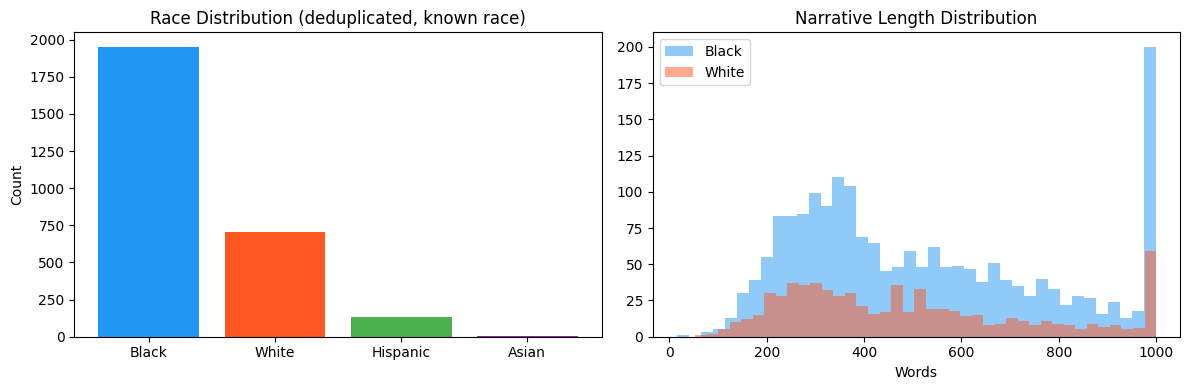

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Race distribution
race_counts = df_clean['race'].value_counts()
axes[0].bar(race_counts.index, race_counts.values, color=['#2196F3','#FF5722','#4CAF50','#9C27B0'])
axes[0].set_title('Race Distribution (deduplicated, known race)')
axes[0].set_ylabel('Count')

# Narrative length distribution by race (Black vs White)
bw = df_clean[df_clean['race'].isin(['Black','White'])]
for race, grp in bw.groupby('race'):
    color = '#2196F3' if race == 'Black' else '#FF5722'
    axes[1].hist(grp['_nar_len'].clip(0, 1000), bins=40, alpha=0.5, label=race, color=color)
axes[1].set_title('Narrative Length Distribution')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/00_data_quality.png', dpi=150)
plt.show()
print('Figure saved.')

## 4. Identifier Detection Audit

In [7]:
# Detect race terms, person names, and location patterns still in narratives

RACE_TERMS = [
    r'\b(black|white|hispanic|latino|latina|african[- ]american|caucasian|asian)\b',
]
NAME_PATTERN = r'\b[A-Z][a-z]+ [A-Z][a-z]+\b'  # Title Case pairs = likely names
ADDR_PATTERN = r'\b\d{2,5}\s+[A-Z][a-z]+\s+(Street|St|Avenue|Ave|Boulevard|Blvd|Road|Rd|Drive|Dr|Place|Pl)\b'

nar_col = 'narrative_clean' if 'narrative_clean' in df_clean.columns else 'narrative'

def audit_narrative(text):
    text = str(text)
    race_hits  = len(re.findall('|'.join(RACE_TERMS), text, re.IGNORECASE))
    name_hits  = len(re.findall(NAME_PATTERN, text))
    addr_hits  = len(re.findall(ADDR_PATTERN, text))
    return race_hits, name_hits, addr_hits

# pandas 3.x safe: build DataFrame from list of tuples, then assign columns
_audit_results = pd.DataFrame(
    df_clean[nar_col].apply(audit_narrative).tolist(),
    columns=['race_hits', 'name_hits', 'addr_hits'],
    index=df_clean.index,
)
df_clean[['race_hits', 'name_hits', 'addr_hits']] = _audit_results

print('Identifier presence in clean narratives:')
print(f'  Race terms present:    {(df_clean["race_hits"] > 0).sum()} / {len(df_clean)} ({100*(df_clean["race_hits"] > 0).mean():.1f}%)')
print(f'  Person names present:  {(df_clean["name_hits"] > 0).sum()} / {len(df_clean)} ({100*(df_clean["name_hits"] > 0).mean():.1f}%)')
print(f'  Addresses present:     {(df_clean["addr_hits"] > 0).sum()} / {len(df_clean)} ({100*(df_clean["addr_hits"] > 0).mean():.1f}%)')
print(f'  Total race term hits:  {df_clean["race_hits"].sum()}')


Identifier presence in clean narratives:
  Race terms present:    400 / 2796 (14.3%)
  Person names present:  2407 / 2796 (86.1%)
  Addresses present:     1344 / 2796 (48.1%)
  Total race term hits:  730


## 5. Enhanced Redaction with Claude API (Batch)

In [8]:
# Redact a representative sample (Black + White, max 500 each)
# Using Claude Haiku for speed and cost efficiency

client = anthropic.Anthropic(api_key=config.ANTHROPIC_API_KEY)

REDACT_PROMPT = """Redact the following police narrative to remove ALL personally identifiable information.
Remove and replace with placeholders:
- Person names (subject, officers, witnesses) → [NAME]
- Specific street addresses → [ADDRESS]
- Race/ethnicity descriptors (black, white, Hispanic, African American, Caucasian, etc.) → [RACE]
- Gender pronouns (he/she/his/her/him) → [PERSON]
- Specific ages → [AGE]

Preserve the structure, force-resistance dynamics, and all action descriptions.
Return ONLY the redacted text, no preamble.

Narrative:
{narrative}"""

def redact_narrative_claude(narrative, client, model=config.CLAUDE_FAST):
    """Redact a single narrative using Claude Haiku."""
    try:
        resp = client.messages.create(
            model=model,
            max_tokens=1024,
            messages=[{"role": "user", "content": REDACT_PROMPT.format(narrative=narrative[:3000])}]
        )
        return resp.content[0].text.strip()
    except Exception:
        return None

print('Claude Haiku redaction ready.')
print('Testing on one narrative...')
nar_col = 'narrative_clean' if 'narrative_clean' in df_clean.columns else 'narrative'
test_nar = df_clean[nar_col].iloc[0]
redacted = redact_narrative_claude(test_nar, client)
print('Original (first 200 chars):', test_nar[:200])
print('Redacted (first 200 chars):', redacted[:200] if redacted else 'FAILED')


Claude Haiku redaction ready.
Testing on one narrative...
Original (first 200 chars): On 10/7/18 at approximately 2110 hours while in full police uniform, I was out with a suspicious vehicle in front of 55 Pardee St. Upon approaching the vehicle I observed a male, later identified as (
Redacted (first 200 chars): On 10/7/18 at approximately 2110 hours while in full police uniform, I was out with a suspicious vehicle in front of [ADDRESS]. Upon approaching the vehicle I observed a [RACE] male, later identified 


In [9]:
# Redact Black + White subset (up to 500 each) for downstream experiments
bw_df = df_clean[df_clean['race'].isin(['Black','White'])].copy()

# pandas 3.x safe groupby sample: use list comprehension instead of groupby().apply()
sample_df = pd.concat([
    g.sample(min(500, len(g)), random_state=config.RANDOM_SEED)
    for _, g in bw_df.groupby('race')
], ignore_index=True)

print(f'Sample for redaction: {len(sample_df)} records')
print(sample_df['race'].value_counts())

# Run redaction (this takes ~15-20 min for 1000 narratives)
redacted_texts = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc='Redacting'):
    nar = str(row[nar_col])[:3000]
    redacted = redact_narrative_claude(nar, client)
    redacted_texts.append(redacted if redacted else nar)  # fallback to original

sample_df['narrative_redacted'] = redacted_texts
sample_df['redaction_success'] = sample_df['narrative_redacted'].notna()
print(f'\nRedaction success rate: {sample_df["redaction_success"].mean():.1%}')


Sample for redaction: 1000 records
race
Black    500
White    500
Name: count, dtype: int64


Redacting:   0%|          | 0/1000 [00:00<?, ?it/s]


Redaction success rate: 100.0%


In [10]:
# Audit redaction quality
def audit_after(text):
    text = str(text)
    race_hits = len(re.findall('|'.join(RACE_TERMS), text, re.IGNORECASE))
    name_hits = len(re.findall(NAME_PATTERN, text))
    return race_hits, name_hits

# pandas 3.x safe: build DataFrame from list of tuples
_after_results = pd.DataFrame(
    sample_df['narrative_redacted'].apply(audit_after).tolist(),
    columns=['race_hits_post', 'name_hits_post'],
    index=sample_df.index,
)
sample_df[['race_hits_post', 'name_hits_post']] = _after_results

before_race = (sample_df['race_hits'] > 0).mean() if 'race_hits' in sample_df.columns else None
after_race  = (sample_df['race_hits_post'] > 0).mean()
after_name  = (sample_df['name_hits_post'] > 0).mean()

print('Post-redaction audit:')
if before_race is not None:
    print(f'  Race terms: {before_race:.1%} → {after_race:.1%}')
print(f'  Person names remaining: {after_name:.1%}')
print(f'  Total residual race hits: {sample_df["race_hits_post"].sum()}')

# Save redacted dataset
sample_df.drop(columns=['race_hits','name_hits','addr_hits','race_hits_post','name_hits_post'], errors='ignore').to_json(
    config.REDACTED_DATA, orient='records', indent=2
)
print(f'\nSaved redacted dataset → {config.REDACTED_DATA}')


Post-redaction audit:
  Race terms: 14.1% → 8.1%
  Person names remaining: 51.2%
  Total residual race hits: 132

Saved redacted dataset → ../../datasets/04_redacted/data_redacted.json


## 6. Train / Test Split Design

In [11]:
# Strategy: Temporal split (no leakage across years) + stratified by race
# Train: 2015-2017 | Test: 2018-2019

bw_clean = df_clean[df_clean['race'].isin(['Black','White'])].copy()
bw_clean['year'] = bw_clean['year'].astype(int)

bw_clean['split'] = bw_clean['year'].apply(lambda y: 'train' if y <= 2017 else 'test')

split_stats = bw_clean.groupby(['split','race']).size().unstack()
print('Temporal split (2015-2017 train, 2018-2019 test):')
print(split_stats)
print(f'\nTrain total: {(bw_clean["split"]=="train").sum()}')
print(f'Test total:  {(bw_clean["split"]=="test").sum()}')

# Check for any CR# overlap (should be zero)
train_crs = set(bw_clean[bw_clean['split']=='train']['cr_number'])
test_crs  = set(bw_clean[bw_clean['split']=='test']['cr_number'])
overlap   = train_crs & test_crs
print(f'\nCR# overlap between train/test: {len(overlap)} (should be 0)')

Temporal split (2015-2017 train, 2018-2019 test):
race   Black  White
split              
test     885    306
train   1067    398

Train total: 1465
Test total:  1191

CR# overlap between train/test: 0 (should be 0)


In [12]:
# Also create balanced subset for probing classifiers
# 500 Black + 500 White from test set (balanced)
n_per_race = 500

# pandas 3.x safe groupby sample
balanced_test = pd.concat([
    g.sample(min(n_per_race, len(g)), random_state=config.RANDOM_SEED)
    for _, g in bw_clean[bw_clean['split']=='test'].groupby('race')
], ignore_index=True)

print(f'Balanced test set: {len(balanced_test)} records')
print(balanced_test['race'].value_counts())

# Save final clean dataset
bw_clean.to_json(config.CLEAN_DATA, orient='records', indent=2)
print(f'\nSaved clean dataset → {config.CLEAN_DATA}')
print(f'Total Black+White records: {len(bw_clean)}')


Balanced test set: 806 records
race
Black    500
White    306
Name: count, dtype: int64

Saved clean dataset → ../../datasets/03_processed/data_clean.json
Total Black+White records: 2656


## 7. Summary Statistics

In [13]:
print('='*60)
print('DATA PIPELINE v2 — SUMMARY')
print('='*60)
print(f'Raw records loaded:          {len(df):,}')
print(f'After deduplication:         {len(df_dedup):,}  (removed {len(df)-len(df_dedup):,} dupes)')
print(f'After quality filter:        {len(df_clean):,}  (known race + narrative ≥10 words)')
print(f'Black+White subset:          {len(bw_clean):,}')
print(f'  → Train (2015-2017):       {(bw_clean["split"]=="train").sum():,}')
print(f'  → Test  (2018-2019):       {(bw_clean["split"]=="test").sum():,}')
print(f'Redacted sample:             {len(sample_df):,}')
print(f'\nOutputs saved:')
print(f'  {config.DEDUP_DATA}')
print(f'  {config.CLEAN_DATA}')
print(f'  {config.REDACTED_DATA}')

DATA PIPELINE v2 — SUMMARY
Raw records loaded:          5,297
After deduplication:         2,974  (removed 2,323 dupes)
After quality filter:        2,796  (known race + narrative ≥10 words)
Black+White subset:          2,656
  → Train (2015-2017):       1,465
  → Test  (2018-2019):       1,191
Redacted sample:             1,000

Outputs saved:
  ../../datasets/03_processed/data_deduplicated.json
  ../../datasets/03_processed/data_clean.json
  ../../datasets/04_redacted/data_redacted.json
